# Neural Network

In [1]:
# pylint: disable=missing-module-docstring
import math
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt

## Load Data

In [2]:
def load_data_npy():
    # pylint: disable=missing-function-docstring

    x = np.load("data/X.npy")
    y = np.load("data/y.npy")
    x = x[0:1000]
    y = y[0:1000]
    return x, y

x_train, y_train = load_data_npy()

print ('The first element of y is: ', y_train[0,0])
print ('The last element of y is: ', y_train[-1,0])
print ('The shape of x is: ' + str(x_train.shape))
print ('The shape of y is: ' + str(y_train.shape))
# print ('The first element of x is: ', x_train[0])

The first element of y is:  0
The last element of y is:  1
The shape of x is: (1000, 400)
The shape of y is: (1000, 1)


## Visualizate the data

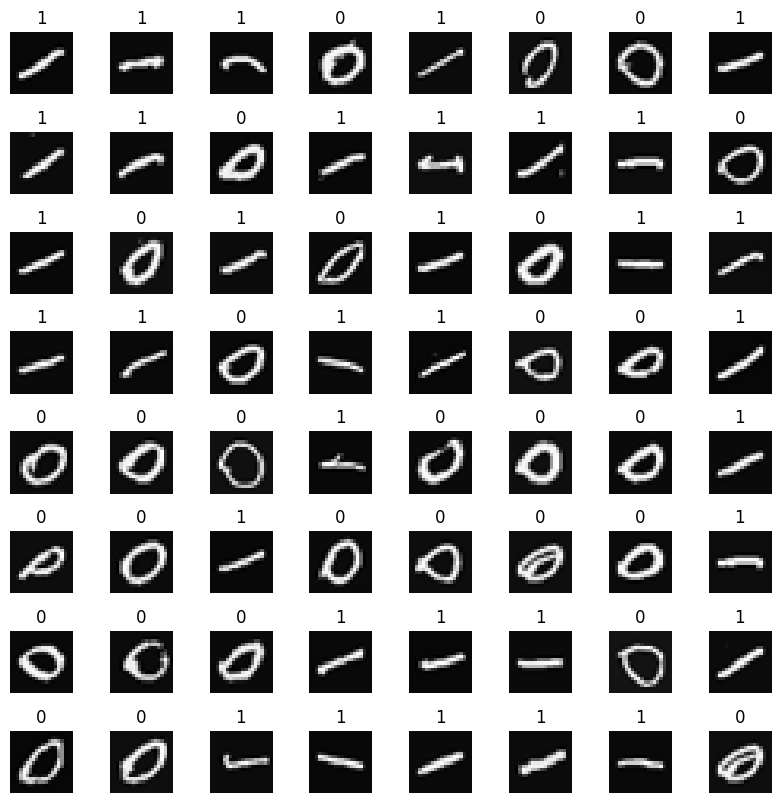

In [4]:
def visualize_data(x: NDArray, y: NDArray):
    # pylint: disable=missing-function-docstring
    m, _ = x.shape

    fig, axes = plt.subplots(8,8, figsize=(8,8))
    fig.tight_layout(pad=0.1)

    for _,ax in enumerate(axes.flat):
        # Select random indices
        random_index = np.random.randint(m)
        
        # Select rows corresponding to the random indices and
        # reshape the image
        x_random_reshaped = x[random_index].reshape((20,20))
        
        # Display the image
        ax.imshow(x_random_reshaped, cmap='gray')
        
        # Display the label above the image
        ax.set_title(y[random_index,0])
        ax.set_axis_off()

visualize_data(x_train, y_train)

Epoch          0: Cost -380.3089
Epoch         50: Cost   1.1554
Epoch        100: Cost  -0.0013
Epoch        150: Cost  -0.0577
Epoch        200: Cost  -0.0538
Epoch        250: Cost  -0.0476
Epoch        300: Cost  -0.0425
Epoch        350: Cost  -0.0384
Epoch        400: Cost  -0.0351
Epoch        450: Cost  -0.0323
X shape: (1000, 400)
y shep: (1000, 1)
p_hat shape: (1000, 1)
[Layer  0] w shape: (400, 25), b shape: (25,)
[Layer  1] w shape: (25, 15), b shape: (15,)
[Layer  2] w shape: (15, 1), b shape: (1,)
Train Accuracy: 50.00%


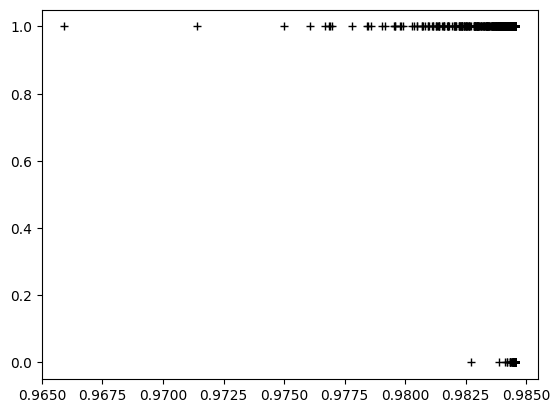

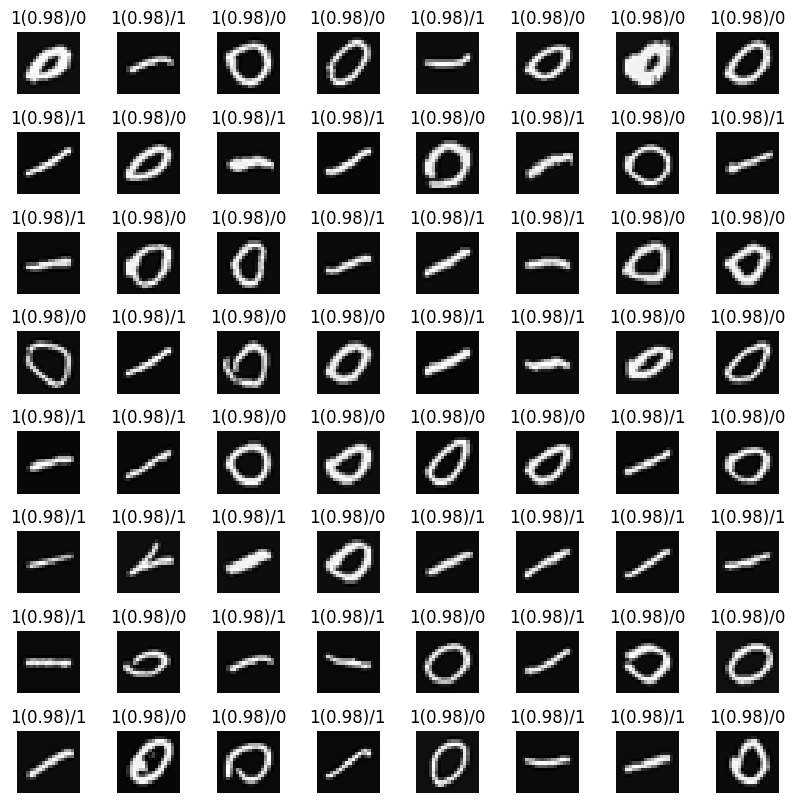

In [ ]:
from abc import abstractmethod
from typing import Tuple

class LossFunction:
    # pylint: disable=missing-class-docstring
    
    @abstractmethod
    def compute_loss(self, p_hat: NDArray, y: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        pass

    @abstractmethod
    def derivative(self, p_hat: NDArray, y: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        pass


class BinaryCrossEntropy(LossFunction):
    # pylint: disable=missing-class-docstring

    def compute_loss(self, p_hat: NDArray, y: NDArray) -> NDArray:
    # pylint: disable=missing-function-docstring
        loss = -y * np.log(p_hat) - (1 - y) * np.log(1 - p_hat)
        return loss

    def derivative(self, p_hat: NDArray, y: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        return (p_hat - y) / (p_hat * (1 - p_hat))

class ActivationFunction:
    # pylint: disable=missing-class-docstring

    def __init__(self):
        # pylint: disable=missing-function-docstring
        pass

    def compute_f(self, x, w, b) -> NDArray:
        # pylint: disable=missing-function-docstring
        z = np.dot(x, w) + b
        return self.activation(z)

    @abstractmethod
    def activation(self, z: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        pass

    @abstractmethod
    def derivative(self, a: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        pass

class SigmoidActivation(ActivationFunction):
    # pylint: disable=missing-class-docstring

    def activation(self, z: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        g = 1 / (1 + np.exp(-z))
        return g

    def derivative(self, a: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        return a * (1 - a)

class ReluActivation(ActivationFunction):
    # pylint: disable=missing-class-docstring

    def activation(self, z: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        return np.max(0, z)

    def derivative(self, a: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        return np.where(a > 0, 1, 0)

class NeuralLayer:
    # pylint: disable=missing-class-docstring

    def __init__(self, units: int, act_function: ActivationFunction, lr: float = 0.01, lambda_: float = 0):
        # pylint: disable=missing-function-docstring
        self.units = units
        self.act_function = act_function
        self.lr = lr
        self.lambda_ = lambda_
        self.w = None
        self.b = None
        self.a_in = None
        self.a_out = None
    
    def set_weights(self, w: NDArray, b: NDArray):
        # pylint: disable=missing-function-docstring
        self.w = w
        self.b = b
    
    def init_weights(self, dim_in: int):
        # pylint: disable=missing-function-docstring
        self.w = 0.5 * (np.random.randn(dim_in, self.units) - 0.5)
        self.b = np.random.randn(self.units)
    
    def weights(self) -> Tuple[NDArray, NDArray]:
        # pylint: disable=missing-function-docstring
        return self.w, self.b

    def forward(self, a_in: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        self.a_in = a_in
        n = a_in.shape[1]
        if self.w is None or self.b is None:
            self.init_weights(n)
        self.a_out = self.act_function.compute_f(a_in, self.w, self.b)
        return self.a_out
    
    def backward(self, dz: NDArray):
        # pylint: disable=missing-function-docstring

        m = self.a_in.shape[0]
        bwd_dz = np.dot(dz, self.w.T) * self.act_function.derivative(self.a_in)
        dj_dw = np.dot(self.a_in.T, dz) / m
        if self.lambda_ != 0:
            dj_dw += (self.lambda_ / m) * self.w
        dj_db = np.sum(dz, axis = 0) / m
        self.w -= self.lr * dj_dw
        self.b -= self.lr * dj_db        
        
        # print(f'shape: dz {dz.shape}, w {self.w.shape}, dj_dw {dj_dw.shape}, b {self.b.shape}, dj_db {dj_db.shape}， bwd_dz {bwd_dz.shape}')
        return bwd_dz

class NeuralNetwork:
    # pylint: disable=missing-class-docstring

    def __init__(self):
        self.layers: list[NeuralLayer] = []
        self.loss_function = BinaryCrossEntropy()
    
    def add_layer(self, layer: NeuralLayer):
        # pylint: disable=missing-function-docstring
        self.layers.append(layer)
    
    def get_layers(self) -> list[NeuralLayer]:
        # pylint: disable=missing-function-docstring
        return self.layers

    def compute_cost(self, p_hat: NDArray, y: NDArray, lambda_: float = 0) -> Tuple[float, NDArray]:
        # pylint: disable=missing-function-docstring

        if (len(self.layers) == 0):
            return [0, np.zeros(0)]

        loss = self.loss_function.compute_loss(p_hat, y)

        m = y.shape[0]
        cost_without_reg = sum(loss.flatten()) / m

        reg_cost = 0
        w_num = 0
        for layer in self.layers:
            w, _ = layer.weights()
            reg_cost += sum(np.square(w.flatten()).flatten())
            w_num += w.shape[1]

        cost = cost_without_reg + (lambda_ / (2 * w_num)) * reg_cost
        return cost, loss

    def forward(self, x) -> NDArray:
        # pylint: disable=missing-function-docstring
        a = x
        for layer in self.layers:
            a = layer.forward(a)
        
        return a
    
    def backward(self, loss: NDArray):
        # pylint: disable=missing-function-docstring
        dz = loss
        for layer in reversed(self.layers):
            dz = layer.backward(dz)

    def fit(self, x: NDArray, y: NDArray, epochs: int, lambda_: float = 0) -> NDArray:
        # pylint: disable=missing-function-docstring
        num_prints = max(1, math.ceil(epochs / 10))
        for i in range(epochs):
            p_hat = self.forward(x)
            cost, loss = self.compute_cost(p_hat, y, lambda_)
            if i % num_prints == 0:
                print(f'Epoch {i:10d}: Cost {cost:8.4f}')
            
            self.backward(loss)

        return p_hat

    def predict(self, x) -> NDArray:
        # pylint: disable=missing-function-docstring
        p_hat = self.forward(x)
        return p_hat


def test_neural_network():
    # pylint: disable=missing-function-docstring
    x_tst = 0.1*np.arange(1,3,1).reshape(1,2)  # (1 examples, 2 features)
    w_tst = 0.1*np.arange(1,7,1).reshape(2,3) # (2 input features, 3 output features)
    b_tst = 0.1*np.arange(1,4,1).reshape(3,)  # (3 features)
    print(f'x_tst shape: {x_tst.shape}, W_tst shape: {w_tst.shape}, b_tst shape: {b_tst.shape}')
    nn_test = NeuralNetwork()
    layer = NeuralLayer(3, SigmoidActivation())
    layer.set_weights(w_tst, b_tst)
    nn_test.add_layer(layer)
    print(nn_test.predict(x_tst))
        
nn = NeuralNetwork()
nn.add_layer(NeuralLayer(25, SigmoidActivation()))
nn.add_layer(NeuralLayer(15, SigmoidActivation()))
nn.add_layer(NeuralLayer(1, SigmoidActivation()))
def train():
    # pylint: disable=missing-function-docstring
    epochs = 500
    p_hat = nn.fit(x_train, y_train, epochs)
    print(f'X shape: {x_train.shape}')
    print(f'y shep: {y_train.shape}')
    print(f'p_hat shape: {p_hat.shape}')
    layers = nn.get_layers()
    for i, layer in enumerate(layers):
        w, b = layer.weights()
        print(f'[Layer {i:2d}] w shape: {w.shape}, b shape: {b.shape}')

    plot_data(p_hat, y_train[:,0], pos_label="y=1", neg_label="y=0")

def plot_data(x, y, pos_label="y=1", neg_label="y=0"):
    # pylint: disable=missing-function-docstring
    positive = x[:,0] > 0.5
    negative = x[:,0] <= 0.5
    # Plot examples
    plt.plot(x[positive, 0], y[positive], 'k+', label=pos_label)
    plt.plot(x[negative, 0], y[negative], 'yo', label=neg_label)


def test_predict():
    # pylint: disable=missing-function-docstring
    p_hat = nn.predict(x_train).flatten()
    p = np.zeros(p_hat.shape[0])
    postive_idx = p_hat > 0.5
    p[postive_idx] = 1
    print(f'Train Accuracy: {np.mean(p == y_train) * 100:3.2f}%')

    m, n = x_train.shape
    fig, axes = plt.subplots(8,8, figsize=(8,8))
    fig.tight_layout(pad=0.1)
    for _,ax in enumerate(axes.flat):
        # Select random indices
        random_index = np.random.randint(m)
        
        # Select rows corresponding to the random indices and
        # reshape the image
        x_random_reshaped = x_train[random_index].reshape((20,20))
        
        # Display the image
        ax.imshow(x_random_reshaped, cmap='gray')
        
        # Display the label above the image
        ax.set_title(f'{int(p[random_index])}({p_hat[random_index]:.2f})/{y_train[random_index,0]}')
        ax.set_axis_off()

# test_neural_network()
train()
test_predict()
